# Notebook: insilico 3G Assembly of mutiple constructs with assembly reports 

## What this notebook does (3-G pipeline)

- Runs **Golden Gate → PCR → Gibson** for many constructs **in one call** via `run_3g_batch_safe(...)`.
- Reads your Excel design (`Constructs`, `TUs`, `PCR`, `Assembly` sheets).
- **Golden Gate:** builds TU(s) from your part folders and writes reports + TU finals.
- **PCR:** simulates backbone (with 5′ overhangs) and TU PCRs (features preserved).
- **Gibson:** merges fragments feature-safely into final constructs.
- Produces a **status table** per ConstructID and writes **GenBank** outputs.
- *(Optional)* **History graphs:** `build_histories_for_all_constructs(...)` renders and saves provenance DAGs.
- *(Optional)* **Feature cleanup:** `remove_near_duplicate_features` to reduce clutter.

---

## Inputs & expected layout

### 1) Excel design file (e.g. `gibson_designs_template.xlsx`)

**Sheets:**

- **`Constructs`**  
  `ConstructID`, `Name` (optional), `Vector` (backbone stem),  
  `MinOverlap` (e.g. 40), `Circularize` (TRUE/FALSE), `Notes` (optional)

- **`TUs`**  *(one row per TU **per construct**)*
  `ConstructID`, `TU` (e.g. `TU1`), `Promoter`, `RBS`, `Gene`, `Terminator`, `UNS_Context`

- **`PCR`**  *(one row per role **per construct**)*
  `ConstructID`, `Role` (`Backbone`, `TU1`, `TU2`, …),  
  `FwdPrimer`, `RevPrimer`, `Circular` (TRUE/FALSE), `MinAnneal` (e.g. 18),  
  `IncludeOverhangs` (TRUE for Backbone, FALSE for TUs), `Notes`

- **`Assembly`**  
  `ConstructID`, `Order` (1,2,3,…), `FragmentRole` (`Backbone`, `TU1`, `TU2`, …)

> The pipeline uses **`MinOverlap`/`Circularize`** from **Constructs**, primers from **PCR**, and fragment **order** from **Assembly**.

### 2) Sequences & folders

- **Parts folders** containing your Golden-Gate parts (used by the recipe builder).
- **Reports folder** (default `./reports`) where results are written:
  - `reports/Assembly/` → TU finals (GenBank) produced by Golden Gate
  - `reports/Finals/` → final Gibson constructs (GenBank)
  - `reports/History/` → optional PNGs of provenance graphs
  - `reports/*_report.zip` → DNA Cauldron reports (optional to keep)

---

## Minimal run example

```python
from pathlib import Path
import pandas as pd

from assembly_designer import (
    run_3g_batch_safe,
    organize_assembly_reports,
    build_histories_for_all_constructs,
)

# 1) Paths
REPORTS_DIR  = Path("reports")
ASSEMBLY_DIR = REPORTS_DIR / "Assembly"

# 2) Load Excel sheets
xl = pd.read_excel("gibson_designs_template.xlsx", sheet_name=None)
constructs_df = xl["Constructs"]
tus_df        = xl.get("TUs", pd.DataFrame())
pcr_df        = xl["PCR"]
assembly_df   = xl["Assembly"]

# 3) Golden-Gate recipe input (example)
category_dirs   = {"Promoter": "parts/Promoters", "RBS": "parts/RBS", "Gene": "parts/Genes", "Terminator": "parts/Terminators"}
designs         = tus_df  # your TU rows act as explicit recipes
category_order  = ["Promoter", "RBS", "Gene", "Terminator", "UNS_Context"]

# 4) Template lookup for PCR (Backbone + TU finals)
from assembly_designer.plasmidio import template_lookup  # provided in your package
vector_rec = ...  # load your backbone SeqRecord earlier (e.g., from GenBank)

# 5) Run Golden Gate → PCR → Gibson
batch = run_3g_batch_safe(
    category_dirs=category_dirs,
    designs=designs,
    category_order=category_order,
    reports_dir=REPORTS_DIR,
    pcr_plan_df=pcr_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    constructs_df=constructs_df,
    template_lookup=template_lookup,  # uses ASSEMBLY_DIR + tus_df + vector_rec
)

# 6) Status table per ConstructID
status_df   = batch.status_df
products    = batch.products
pcr_results = batch.pcr_results
finals      = batch.finals
display(status_df)

# 7) (Optional) History graphs
histories = build_histories_for_all_constructs(
    constructs_df=constructs_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    vector_rec=vector_rec,
    products=products,
    pcr_results=pcr_results,
    finals=finals,
    plot=True,
    save_png_dir=REPORTS_DIR / "History",
)
``` 
---

## Outputs

- **Golden Gate:** `reports/Assembly/*.gb*` (TU finals) and `*_report.zip` archives.  
- **PCR:** in-memory products (see `batch.products`).  
- **Gibson:** `reports/Finals/<CID>_final.gb` files (see `batch.finals`).  
- **Status table:** `batch.status_df` with `gg_ok`, `pcr_ok`, `gibson_ok`, messages, and final sizes/paths.  
- **History graphs (optional):** `reports/History/<CID>_history.png`.

---

## Tips

- If your TU finals aren’t found: check that `REPORTS_DIR / "Assembly"` exists **and** that Golden Gate created `.gb` files there.  
- White PNGs usually mean a blank Matplotlib canvas—make sure you call `hist.plot(...)` **before** saving, and call `plt.close()` if you draw in loops.  
- To de-clutter features on the final constructs, call `remove_near_duplicate_features(final)` before writing the GenBank file.


In [2]:
 # ========================= 1) 3G batch runner + history (top-level re-exports) =========================== 

from assembly_designer import (
    run_3g_batch_safe,          # batch wrapper: GG → PCR → Gibson
    BuildStatus,                # status dataclass returned per ConstructID
    AssemblyHistory,            # provenance graph (optional, for plotting)
    build_histories_for_all_constructs,  # convenience: one history per CID
)

import re
import os
import pandas as pd

from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

from assembly_designer.plasmidio import load_dna_file, remove_near_duplicate_features, make_template_lookup

# Typing helper if you annotate template_lookup
from typing import Callable

import matplotlib.pyplot as plt   # used by AssemblyHistory.plot()
import networkx as nx             # used by AssemblyHistory.plot()

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Optional, Sequence, Tuple



In [3]:
# ========================= 2) Configuration ===========================
BASE_DIR = Path.cwd()

# Where Golden Gate report ZIPs, TU finals, and Gibson finals will be written.
# ⚠️ IMPORTANT: The lazy `template_lookup` below reads from this same folder.
REPORTS_DIR = BASE_DIR / "reports"
ASSEMBLY_DIR = REPORTS_DIR / "Assembly"  # TU finals (GenBank) end up here

# Exact order of categories per TU design (and their folders)
category_order: Sequence[str] = ["Promoter", "RBS", "Gene", "Terminator", "UNS_Context"]

folder_paths = [
    BASE_DIR / "01_Promoter_Parts",
    BASE_DIR / "02_RBS_Parts",
    BASE_DIR / "03_Gene_of_Interest_Parts",
    BASE_DIR / "04_Terminator_Parts",
    BASE_DIR / "05_UNS_Context_Parts",
]
category_dirs: Dict[str, Path] = dict(zip(category_order, folder_paths))

# Find and load the backbone (prefer .dna if available)
CANDIDATES = [BASE_DIR / "06_Gibson_Backbone_Parts",
              BASE_DIR / "Backbone_Parts",
              BASE_DIR / "Backbone_parts"]
vec_dir = next((d for d in CANDIDATES if d.is_dir()), None)
if vec_dir is None:
    raise FileNotFoundError(f"No backbone folder found in {CANDIDATES}")

vec_files = [p for p in vec_dir.iterdir() if p.suffix.lower() in {".dna", ".gb", ".gbk", ".genbank"}]
if not vec_files:
    raise FileNotFoundError(f"No vector files in {vec_dir}")

vector_path = next((p for p in vec_files if p.suffix.lower() == ".dna"), vec_files[0])
vector_rec: SeqRecord = load_dna_file(vector_path)
vector_rec.id = vector_rec.name = vector_path.stem
vector_rec.annotations.setdefault("molecule_type", "DNA")
print("Vector:", vector_rec.id)



Vector: pEVmC(K)_AE


In [4]:
# ========================= 3) Load Excel sheets =======================
xlsx_path = "gibson_designs_template.xlsx"
xl = pd.read_excel(xlsx_path, sheet_name=None)

constructs_df = xl.get("Constructs", pd.DataFrame()).copy()
pcr_df        = xl["PCR"].copy()
assembly_df   = xl["Assembly"].copy()
tus_df        = xl.get("TUs", pd.DataFrame()).copy()

# The Golden Gate "designs": one dict per TU (columns must match category_order)
# Typically this is just the "TUs" sheet.
designs = tus_df.to_dict("records")

In [5]:
def template_lookup(cid, role):
    """Explicit lookup: TUs sheet → TU_Final_ID → GenBank file."""
    role_s = str(role).strip()
    if role_s.lower() == "backbone":
        return vector_rec

    # Direct mapping from TUs sheet
    row = tus_df[(tus_df["ConstructID"].astype(str) == str(cid)) &
                 (tus_df["TU"].astype(str).str.upper() == str(role_s).upper())]
    if row.empty:
        raise ValueError(f"No TU row for ({cid}, {role})")

    tu_final_id = str(row.iloc[0].get("TU_Final_ID", "")).strip()
    if not tu_final_id:
        raise ValueError(f"No TU_Final_ID for ({cid}, {role})")

    # Load the specific GenBank file
    final_path = Path(REPORTS_DIR) / "Assembly" / f"{tu_final_id}.gb"
    if not final_path.exists():
        raise FileNotFoundError(f"TU final not found: {final_path}")

    rec = SeqIO.read(str(final_path), "genbank")
    rec.id = rec.name = final_path.stem
    rec.annotations.setdefault("molecule_type", "DNA")
    return rec

In [6]:
# 1) Run the batch (GG → PCR → Gibson)
batch = run_3g_batch_safe(
    category_dirs=category_dirs,
    designs=designs,
    category_order=category_order,
    reports_dir=REPORTS_DIR,
    pcr_plan_df=pcr_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    constructs_df=constructs_df,
    template_lookup=template_lookup,
)

In [ ]:
# delete near-duplicate features in all extracted GenBank files
# (optional, but recommended if your parts have overlapping annotations)
assembly_folder = Path("reports") / "Finals"

for file_name in os.listdir(assembly_folder):
    if file_name.endswith(".gb") or file_name.endswith(".gbk"):
        file_path = os.path.join(assembly_folder, file_name)
        remove_near_duplicate_features(file_path, tolerance=3)  # Tolerance of ±3 bases

✅ Cleaned file saved: reports\Finals\C01_final.gb
✅ Cleaned file saved: reports\Finals\C02_final.gb
✅ Cleaned file saved: reports\Finals\C03_final.gb


In [8]:
# 2) Unpack artifacts you need for the history
status_df   = batch.status_df
products    = batch.products         # dict[(cid, role)] -> PCR product (SeqRecord)
pcr_results = batch.pcr_results      # dict[(cid, role)] -> PCRResult (optional)
finals      = batch.finals           # dict[cid] -> final Gibson SeqRecord

display(status_df)

,gg_ok,gg_msg,pcr_ok,pcr_msg,gibson_ok,gibson_msg,final_path,final_bp
cid,,,,,,,,
C01,True,,True,,True,,c:\Users\koesters\Sciebo\Git\Repositories\asse...,9279
C02,True,,True,,True,,c:\Users\koesters\Sciebo\Git\Repositories\asse...,9334
C03,True,,True,,True,,c:\Users\koesters\Sciebo\Git\Repositories\asse...,9334


In [ ]:
import re
from pathlib import Path

def safe_filename(name: str) -> str:
    s = str(name).strip()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r'[<>:"/\\|?*]+', "_", s)
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:120] or "unnamed_construct"

finals_dir = Path(REPORTS_DIR) / "Finals"
finals_dir.mkdir(parents=True, exist_ok=True)

for cid, final_rec in batch.finals.items():
    construct_row = constructs_df[constructs_df["ConstructID"].astype(str) == str(cid)]
    if construct_row.empty:
        continue

    name = str(construct_row.iloc[0].get("Name", "")).strip()
    if not name:
        continue

    safe_name = safe_filename(name)
    old_path = finals_dir / f"{cid}_final.gb"
    new_path = finals_dir / f"{safe_name}_final.gb"

    final_rec.id = safe_name
    final_rec.name = safe_name

    if old_path.exists() and old_path != new_path:
        old_path.replace(new_path)  # os.replace: overwrites on Windows too, unlike os.rename

    SeqIO.write(final_rec, new_path, "genbank")
    print(f"Renamed: {cid} → {safe_name}")

C:\Users\koesters\Sciebo\Git\Repositories\assembly_designer\assembly_designer\plasmidio\plasmidio.py:9621: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


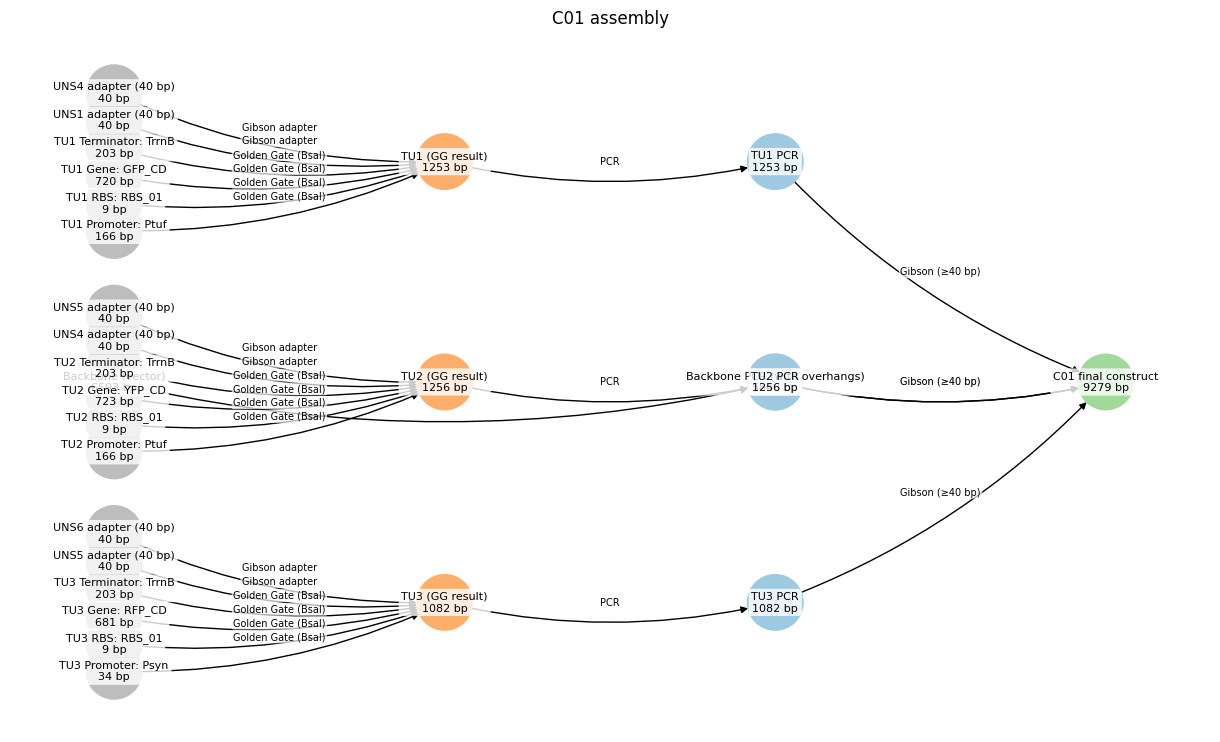

C:\Users\koesters\Sciebo\Git\Repositories\assembly_designer\assembly_designer\plasmidio\plasmidio.py:9621: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


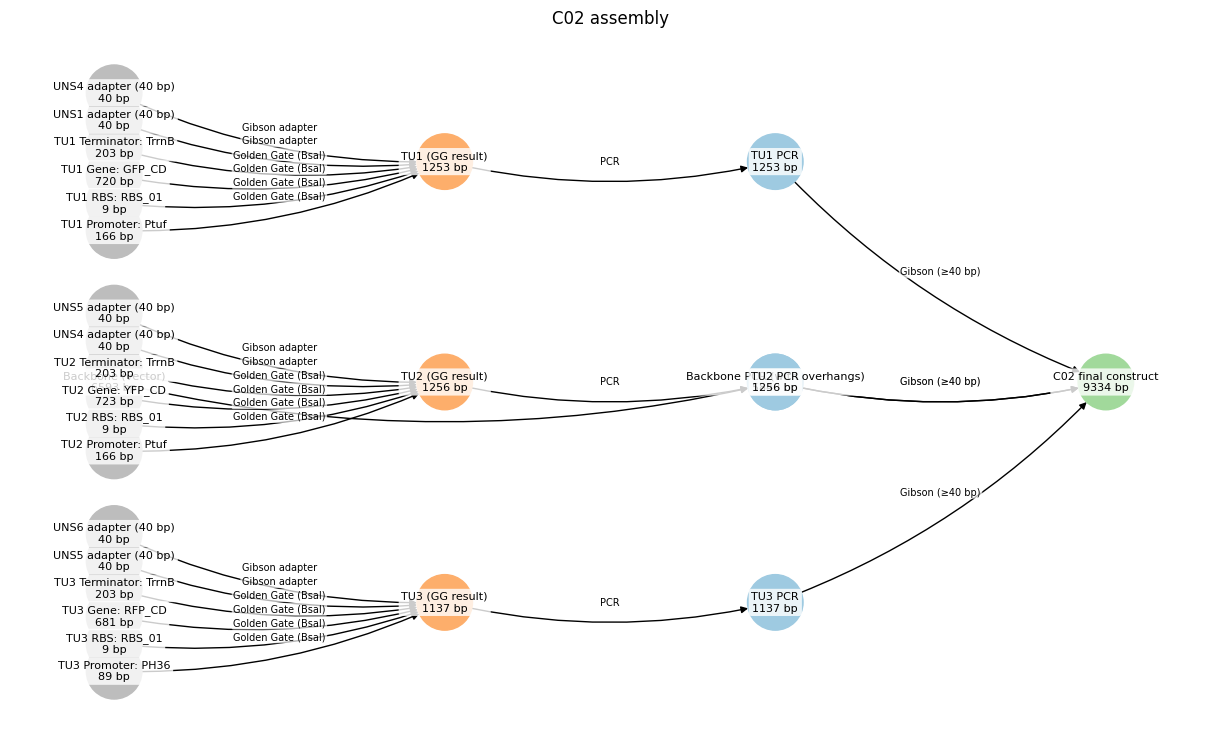

C:\Users\koesters\Sciebo\Git\Repositories\assembly_designer\assembly_designer\plasmidio\plasmidio.py:9621: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


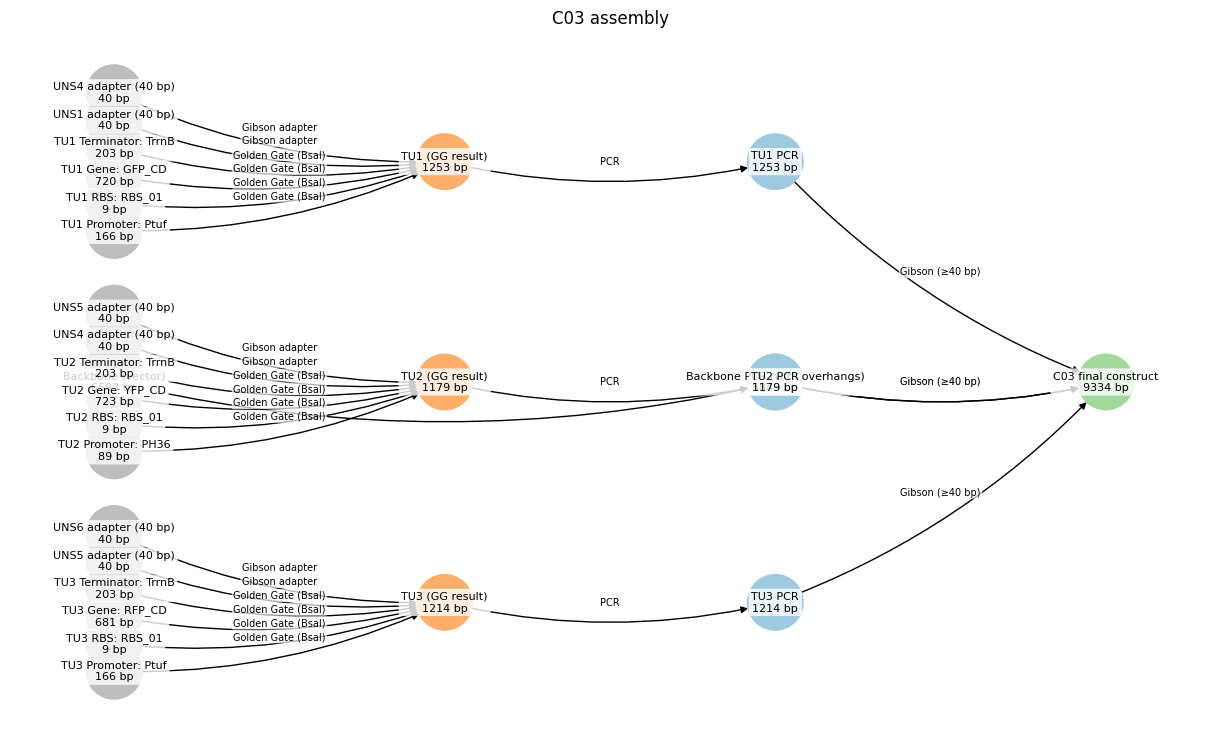

In [10]:
# 3) Build + plot histories (and save PNGs)
histories = build_histories_for_all_constructs(
    constructs_df=constructs_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    vector_rec=vector_rec,
    products=products,
    pcr_results=pcr_results,
    finals=finals,
    plot=True,
    save_png_dir=Path("reports/History"),
)
